In [4]:
import pandas as pd
from pathlib import Path

RUTA_RAW = Path("../Datos/Raw/accidentes.csv")
LLAVES = ["BARRIO", "TW"]

accidentes_raw = pd.read_csv(RUTA_RAW, parse_dates=["TW"])
print(f"accidentes_raw: {len(accidentes_raw):,} filas × {accidentes_raw.shape[1]} columnas")
print(f"Duplicados en {LLAVES}: {accidentes_raw.duplicated(LLAVES).sum():,}")
accidentes_raw.head()

accidentes_raw: 120,587 filas × 8 columnas
Duplicados en ['BARRIO', 'TW']: 0


,TW,BARRIO,Lat,Lon,Dia_sem,Mes,Dia,Hora
0,2017-07-20 08:00:00,sandiego,6.233985,-75.570146,JUEVES,7,20,8
1,2017-06-15 16:00:00,lasacacias,6.238844,-75.600280,JUEVES,6,15,16
2,2017-07-02 16:00:00,lopezdemesa,6.285074,-75.584306,DOMINGO,7,2,16
3,2017-03-29 18:00:00,losconquistadores,6.239497,-75.583062,MIERCOLES,3,29,18
4,2017-07-26 20:00:00,cuartabrigada,6.260463,-75.590193,MIERCOLES,7,26,20


In [5]:
RUTA_FEATURES = Path("../Datos/Trusted/features_accidentes.csv")

features_accidentes = pd.read_csv(RUTA_FEATURES, parse_dates=["TW"])
print(f"features_accidentes: {len(features_accidentes):,} filas × {features_accidentes.shape[1]} columnas")
print(f"Duplicados en {LLAVES}: {features_accidentes.duplicated(LLAVES).sum():,}")
features_accidentes.head()

features_accidentes: 125,122 filas × 13 columnas
Duplicados en ['BARRIO', 'TW']: 4,535


,BARRIO,COMUNA,TW,es_fin_semana,es_festivo,hora_sin,hora_cos,dia_semana_sin,dia_semana_cos,dia_ano_sin,dia_ano_cos,comuna_ext,prom_accidentes_historico_barrio
0,cabecerasanantoniodeprado,Corregimiento de San Antonio de Prado,2017-01-01 03:00:00,1,1,0.707107,0.707107,-0.781831,0.62349,0.017213,0.999852,80.0,0.0
1,cabecerasanantoniodeprado,Corregimiento de San Antonio de Prado,2017-01-01 16:00:00,1,1,-0.866025,-0.500000,-0.781831,0.62349,0.017213,0.999852,80.0,0.0
2,kennedy,Doce de Octubre,2017-01-01 01:00:00,1,1,0.258819,0.965926,-0.781831,0.62349,0.017213,0.999852,6.0,0.0
3,areadeexpansionpajarito,Corregimiento de San Cristóbal,2017-01-01 08:00:00,1,1,0.866025,-0.500000,-0.781831,0.62349,0.017213,0.999852,60.0,0.0
4,asomaderano3,Buenos Aires,2017-01-01 19:00:00,1,1,-0.965926,0.258819,-0.781831,0.62349,0.017213,0.999852,9.0,0.0


## Join: `features_accidentes` + accidentes raw

Llaves: **`BARRIO`** + **`TW`** (misma unidad espacio-temporal que clima ↔ accidentes).

In [6]:
# Inner: todas las filas de features con su registro raw (Lat/Lon, Mes, Dia, Hora...)
# Si una llave BARRIO+TW se repite en features, el merge repite la fila raw.
accidentes_join = features_accidentes.merge(
    accidentes_raw,
    on=LLAVES,
    how="inner",
    suffixes=("", "_raw"),
    validate="many_to_one",  # muchas features → una fila raw por llave
)

print(f"Filas tras join (inner): {len(accidentes_join):,}")
print(f"Columnas: {accidentes_join.shape[1]}")
print("\nColumnas del join:")
print(accidentes_join.columns.tolist())

# Validación rápida
assert len(accidentes_join) == len(features_accidentes), "Se perdieron filas de features en el inner join"
print("\n✓ Todas las filas de features_accidentes tienen match en raw.")

accidentes_join.head()

Filas tras join (inner): 125,122
Columnas: 19

Columnas del join:
['BARRIO', 'COMUNA', 'TW', 'es_fin_semana', 'es_festivo', 'hora_sin', 'hora_cos', 'dia_semana_sin', 'dia_semana_cos', 'dia_ano_sin', 'dia_ano_cos', 'comuna_ext', 'prom_accidentes_historico_barrio', 'Lat', 'Lon', 'Dia_sem', 'Mes', 'Dia', 'Hora']

✓ Todas las filas de features_accidentes tienen match en raw.


,BARRIO,COMUNA,TW,es_fin_semana,es_festivo,hora_sin,hora_cos,dia_semana_sin,dia_semana_cos,dia_ano_sin,dia_ano_cos,comuna_ext,prom_accidentes_historico_barrio,Lat,Lon,Dia_sem,Mes,Dia,Hora
0,cabecerasanantoniodeprado,Corregimiento de San Antonio de Prado,2017-01-01 03:00:00,1,1,0.707107,0.707107,-0.781831,0.62349,0.017213,0.999852,80.0,0.0,6.185473,-75.648182,DOMINGO,1,1,3
1,cabecerasanantoniodeprado,Corregimiento de San Antonio de Prado,2017-01-01 16:00:00,1,1,-0.866025,-0.500000,-0.781831,0.62349,0.017213,0.999852,80.0,0.0,6.186579,-75.648998,DOMINGO,1,1,16
2,kennedy,Doce de Octubre,2017-01-01 01:00:00,1,1,0.258819,0.965926,-0.781831,0.62349,0.017213,0.999852,6.0,0.0,6.287505,-75.581983,DOMINGO,1,1,1
3,areadeexpansionpajarito,Corregimiento de San Cristóbal,2017-01-01 08:00:00,1,1,0.866025,-0.500000,-0.781831,0.62349,0.017213,0.999852,60.0,0.0,6.284049,-75.613491,DOMINGO,1,1,8
4,asomaderano3,Buenos Aires,2017-01-01 19:00:00,1,1,-0.965926,0.258819,-0.781831,0.62349,0.017213,0.999852,9.0,0.0,6.214653,-75.557658,DOMINGO,1,1,19


## Join con `clima_limpio.csv`

`accidentes_join` ya trae features (`hora_sin`, `prom_accidentes_historico_barrio`, …) + raw. Solo falta pegar el clima por **`BARRIO` + `TW`** → tabla final **`accidentes_clima`**.

In [7]:
RUTA_CLIMA = Path("../Datos/Staging/clima_limpio.csv")

clima = pd.read_csv(RUTA_CLIMA, parse_dates=["TW"])
print(f"clima: {len(clima):,} filas × {clima.shape[1]} columnas")
print(f"Duplicados en {LLAVES}: {clima.duplicated(LLAVES).sum():,}")
clima.head()

clima: 7,436,188 filas × 13 columnas
Duplicados en ['BARRIO', 'TW']: 0


,TW,BARRIO,summary,precipIntensity,precipProbability,temperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility
0,2017-01-01 00:00:00,aguasfrias,Partly Cloudy,0.0,0.0,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004
1,2017-01-01 01:00:00,aguasfrias,Partly Cloudy,0.0,0.0,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004
2,2017-01-01 02:00:00,aguasfrias,Foggy,0.0,0.0,15.43,13.0,0.85,1.02,90.0,0.44,0.0,2.997
3,2017-01-01 03:00:00,aguasfrias,Foggy,0.0,0.0,15.43,13.0,0.85,2.09,140.0,0.44,0.0,0.199
4,2017-01-01 04:00:00,aguasfrias,Foggy,0.0,0.0,15.43,13.0,0.85,2.09,350.0,1.00,0.0,0.099


In [8]:
# Tabla para el modelo: todo lo de accidentes_join + clima en la misma barrio-hora
accidentes_clima = accidentes_join.merge(
    clima,
    on=LLAVES,
    how="left",
    validate="many_to_one",
)

sin_clima = accidentes_clima["temperature"].isna().sum()
print(f"accidentes_clima: {len(accidentes_clima):,} filas × {accidentes_clima.shape[1]} columnas")
print(f"Sin lectura climática (temperature NaN): {sin_clima:,} ({100 * sin_clima / len(accidentes_clima):.2f}%)")
print("\nColumnas:", accidentes_clima.columns.tolist())

accidentes_clima.head()

accidentes_clima: 125,122 filas × 30 columnas
Sin lectura climática (temperature NaN): 8,305 (6.64%)

Columnas: ['BARRIO', 'COMUNA', 'TW', 'es_fin_semana', 'es_festivo', 'hora_sin', 'hora_cos', 'dia_semana_sin', 'dia_semana_cos', 'dia_ano_sin', 'dia_ano_cos', 'comuna_ext', 'prom_accidentes_historico_barrio', 'Lat', 'Lon', 'Dia_sem', 'Mes', 'Dia', 'Hora', 'summary', 'precipIntensity', 'precipProbability', 'temperature', 'dewPoint', 'humidity', 'windSpeed', 'windBearing', 'cloudCover', 'uvIndex', 'visibility']


,BARRIO,COMUNA,TW,es_fin_semana,es_festivo,hora_sin,hora_cos,dia_semana_sin,dia_semana_cos,dia_ano_sin,...,precipIntensity,precipProbability,temperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility
0,cabecerasanantoniodeprado,Corregimiento de San Antonio de Prado,2017-01-01 03:00:00,1,1,0.707107,0.707107,-0.781831,0.62349,0.017213,...,0.0,0.0,15.03,13.00,0.88,2.09,140.0,0.44,0.0,0.199
1,cabecerasanantoniodeprado,Corregimiento de San Antonio de Prado,2017-01-01 16:00:00,1,1,-0.866025,-0.500000,-0.781831,0.62349,0.017213,...,0.0,0.0,27.25,14.72,0.46,2.83,150.0,0.41,2.0,10.003
2,kennedy,Doce de Octubre,2017-01-01 01:00:00,1,1,0.258819,0.965926,-0.781831,0.62349,0.017213,...,0.0,0.0,16.84,14.00,0.83,1.50,0.0,0.44,0.0,6.004
3,areadeexpansionpajarito,Corregimiento de San Cristóbal,2017-01-01 08:00:00,1,1,0.866025,-0.500000,-0.781831,0.62349,0.017213,...,0.0,0.0,18.14,15.74,0.86,0.13,170.0,0.77,1.0,7.459
4,asomaderano3,Buenos Aires,2017-01-01 19:00:00,1,1,-0.965926,0.258819,-0.781831,0.62349,0.017213,...,0.0,0.0,22.56,15.82,0.66,2.91,210.0,0.44,0.0,10.003


## `df_modelo`: clima + `accidentes_join` → `target` 0 / 1

`clima` a la izquierda: si esa `BARRIO`+`TW` está en accidentes → `target=1`, si no → `target=0`.

In [9]:
df_modelo = clima.merge(
    accidentes_join.drop_duplicates(subset=LLAVES, keep="last"),
    on=LLAVES,
    how="left",
    indicator=True,
)

df_modelo["target"] = (df_modelo["_merge"] == "both").astype("int8")
df_modelo = df_modelo.drop(columns="_merge")

print(f"df_modelo: {len(df_modelo):,} filas × {df_modelo.shape[1]} columnas\n")

resumen_target = (
    df_modelo["target"]
    .value_counts()
    .rename(index={0: "target=0", 1: "target=1"})
    .rename("cantidad")
    .to_frame()
)
resumen_target["porcentaje"] = (resumen_target["cantidad"] / len(df_modelo) * 100).round(4)
resumen_target["porcentaje_str"] = resumen_target["porcentaje"].map(lambda x: f"{x:.4f}%")
display(resumen_target)

df_modelo.head()

df_modelo: 7,436,188 filas × 31 columnas



,cantidad,porcentaje,porcentaje_str
target,,,
target=0,7323613,98.4861,98.4861%
target=1,112575,1.5139,1.5139%


,TW,BARRIO,summary,precipIntensity,precipProbability,temperature,dewPoint,humidity,windSpeed,windBearing,...,dia_ano_cos,comuna_ext,prom_accidentes_historico_barrio,Lat,Lon,Dia_sem,Mes,Dia,Hora,target
0,2017-01-01 00:00:00,aguasfrias,Partly Cloudy,0.0,0.0,16.43,14.0,0.86,1.50,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2017-01-01 01:00:00,aguasfrias,Partly Cloudy,0.0,0.0,16.43,14.0,0.86,1.50,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2017-01-01 02:00:00,aguasfrias,Foggy,0.0,0.0,15.43,13.0,0.85,1.02,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2017-01-01 03:00:00,aguasfrias,Foggy,0.0,0.0,15.43,13.0,0.85,2.09,140.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2017-01-01 04:00:00,aguasfrias,Foggy,0.0,0.0,15.43,13.0,0.85,2.09,350.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [10]:
!pip install holidays

## Codificación cíclica (seno/coseno) desde `TW`

Igual que en `eda_accidentes_agg`: se calcula en **todas** las filas de `df_modelo` (target 0 y 1), porque el merge solo trae esas columnas cuando hubo accidente.

In [11]:
import numpy as np

ts = pd.to_datetime(df_modelo["TW"])
hora_dia = ts.dt.hour
dia_semana = ts.dt.dayofweek
dia_del_ano = ts.dt.dayofyear.astype(float)
dias_totales_ano = ts.dt.is_leap_year.map(lambda bis: 366.0 if bis else 365.0)

# Calendario (misma lógica que accidentes)
df_modelo["es_fin_semana"] = dia_semana.isin([5, 6]).astype(np.int8)
try:
    import holidays

    festivos_co = holidays.Colombia(years=[2017, 2018, 2019])
    df_modelo["es_festivo"] = ts.dt.date.map(lambda d: np.int8(1 if d in festivos_co else 0))
except ImportError:
    df_modelo["es_festivo"] = np.int8(0)
    print("Aviso: instala holidays (pip install holidays) para es_festivo exacto.")

# Seno y coseno: hora, día de la semana, día del año
df_modelo["hora_sin"] = np.sin(2 * np.pi * hora_dia / 24.0)
df_modelo["hora_cos"] = np.cos(2 * np.pi * hora_dia / 24.0)
df_modelo["dia_semana_sin"] = np.sin(2 * np.pi * dia_semana / 7.0)
df_modelo["dia_semana_cos"] = np.cos(2 * np.pi * dia_semana / 7.0)
df_modelo["dia_ano_sin"] = np.sin(2 * np.pi * dia_del_ano / dias_totales_ano)
df_modelo["dia_ano_cos"] = np.cos(2 * np.pi * dia_del_ano / dias_totales_ano)

print("Variables cíclicas aplicadas desde TW en todas las filas.")
print(
    df_modelo[["TW", "hora_sin", "hora_cos", "dia_semana_sin", "dia_ano_sin", "dia_ano_cos", "target"]]
    .head()
)

Variables cíclicas aplicadas desde TW en todas las filas.
                   TW  hora_sin  hora_cos  dia_semana_sin  dia_ano_sin  \
0 2017-01-01 00:00:00  0.000000  1.000000       -0.781831     0.017213   
1 2017-01-01 01:00:00  0.258819  0.965926       -0.781831     0.017213   
2 2017-01-01 02:00:00  0.500000  0.866025       -0.781831     0.017213   
3 2017-01-01 03:00:00  0.707107  0.707107       -0.781831     0.017213   
4 2017-01-01 04:00:00  0.866025  0.500000       -0.781831     0.017213   

   dia_ano_cos  target  
0     0.999852       0  
1     0.999852       0  
2     0.999852       0  
3     0.999852       0  
4     0.999852       0  


In [12]:
import holidays
import numpy as np
import pandas as pd

ts = pd.to_datetime(df_modelo["TW"])

# Crear calendario de festivos de Colombia según los años presentes en tu dataset
anios = sorted(ts.dt.year.unique())

festivos_co = holidays.Colombia(years=anios)

df_modelo["es_festivo"] = ts.dt.date.map(
    lambda d: np.int8(1 if d in festivos_co else 0)
)

print("Festivos calculados correctamente.")
print(df_modelo["es_festivo"].value_counts())

# Validación rápida: 1 de enero debería ser festivo
df_modelo.loc[df_modelo["TW"].dt.date == pd.to_datetime("2017-01-01").date(), 
              ["TW", "es_festivo"]].head()

Festivos calculados correctamente.
es_festivo
0    7078540
1     357648
Name: count, dtype: int64


,TW,es_festivo
0,2017-01-01 00:00:00,1
1,2017-01-01 01:00:00,1
2,2017-01-01 02:00:00,1
3,2017-01-01 03:00:00,1
4,2017-01-01 04:00:00,1


In [13]:
import pandas as pd
import numpy as np

# =========================================================
# RECONSTRUIR prom_accidentes_historico_barrio SIN FUGA
# =========================================================

df_modelo = df_modelo.copy()

# Asegurar tipos
df_modelo["TW"] = pd.to_datetime(df_modelo["TW"])
df_modelo["BARRIO"] = df_modelo["BARRIO"].astype(str).str.strip().str.lower()
df_modelo["target"] = df_modelo["target"].astype(int)

# Eliminar versión anterior si estaba mal construida
df_modelo = df_modelo.drop(
    columns=["prom_accidentes_historico_barrio"],
    errors="ignore"
)

# Guardar índice original para volver al orden inicial
df_modelo["_orden_original"] = np.arange(len(df_modelo))

# Ordenar por barrio y tiempo
df_modelo = df_modelo.sort_values(["BARRIO", "TW"]).reset_index(drop=True)

# Conteo acumulado previo de registros por barrio
df_modelo["registros_previos_barrio"] = (
    df_modelo
    .groupby("BARRIO")
    .cumcount()
)

# Accidentes acumulados previos por barrio (shift evita usar el target de la fila actual)
df_modelo["accidentes_previos_barrio"] = (
    df_modelo.groupby("BARRIO")["target"]
    .transform(lambda s: s.cumsum().shift(1))
    .fillna(0)
)

# Promedio histórico previo de accidentes por barrio
df_modelo["prom_accidentes_historico_barrio"] = np.where(
    df_modelo["registros_previos_barrio"] > 0,
    df_modelo["accidentes_previos_barrio"] / df_modelo["registros_previos_barrio"],
    0
)

# Volver al orden original
df_modelo = (
    df_modelo
    .sort_values("_orden_original")
    .drop(columns=["_orden_original"])
    .reset_index(drop=True)
)

# Optimizar tipo de dato
df_modelo["prom_accidentes_historico_barrio"] = (
    df_modelo["prom_accidentes_historico_barrio"].astype("float32")
)

print("Variable histórica reconstruida correctamente.")
print(df_modelo["prom_accidentes_historico_barrio"].describe())
print(f"NaN en prom: {df_modelo['prom_accidentes_historico_barrio'].isna().sum():,}")

display(
    df_modelo[
        [
            "BARRIO",
            "TW",
            "target",
            "registros_previos_barrio",
            "accidentes_previos_barrio",
            "prom_accidentes_historico_barrio"
        ]
    ].head(20)
)

Variable histórica reconstruida correctamente.
count    7.436188e+06
mean     1.492597e-02
std      1.762819e-02
min      0.000000e+00
25%      3.187251e-03
50%      9.244992e-03
75%      1.963916e-02
max      1.000000e+00
Name: prom_accidentes_historico_barrio, dtype: float64
NaN en prom: 0


,BARRIO,TW,target,registros_previos_barrio,accidentes_previos_barrio,prom_accidentes_historico_barrio
0,aguasfrias,2017-01-01 00:00:00,0,0,0.0,0.0
1,aguasfrias,2017-01-01 01:00:00,0,1,0.0,0.0
2,aguasfrias,2017-01-01 02:00:00,0,2,0.0,0.0
3,aguasfrias,2017-01-01 03:00:00,0,3,0.0,0.0
4,aguasfrias,2017-01-01 04:00:00,0,4,0.0,0.0
5,aguasfrias,2017-01-01 05:00:00,0,5,0.0,0.0
6,aguasfrias,2017-01-01 06:00:00,0,6,0.0,0.0
7,aguasfrias,2017-01-01 07:00:00,0,7,0.0,0.0
8,aguasfrias,2017-01-01 08:00:00,0,8,0.0,0.0
9,aguasfrias,2017-01-01 09:00:00,0,9,0.0,0.0


In [14]:
# ⚠️ NO ejecutar esta celda antes de **reconstruir `prom_accidentes_historico_barrio`** (celda siguiente).
# Si la corres antes, `df_features` queda con NaN en `prom` (viene vacío del merge con accidentes).
# Usa la celda final **"RECONSTRUIR df_features"** después de la reconstrucción del promedio histórico.

# =========================================================
# BLOQUE — LIMPIEZA (opcional; preferir celda final de df_features)
# =========================================================

# Columnas que vinieron desde accidentes y NO deben usarse directamente en el modelo
cols_accidentes_no_modelo = [
    "Lat",
    "Lon",
    "Dia_sem",
    "Mes",
    "Dia",
    "Hora"
]

# Columnas temporales crudas/redundantes si existen
cols_temporales_crudas = [
    "hora",
    "dia_semana",
    "dia_ano",
    "dia",
    "mes",
    "anio"
]

# Variables climáticas que decidiste eliminar por EDA
cols_clima_eliminar = [
    "precipIntensity",
    "precipProbability",
    "visibility",
    "cloudCover"
]

# Si ya tienes windBearing_sin/cos, no necesitas windBearing crudo ni radianes
cols_ciclicas_crudas = [
    "windBearing",
    "windBearing_rad"
]

cols_a_eliminar = (
    cols_accidentes_no_modelo
    + cols_temporales_crudas
    + cols_clima_eliminar
    + cols_ciclicas_crudas
)

df_features = df_modelo.drop(columns=cols_a_eliminar, errors="ignore").copy()

print("Columnas eliminadas:")
print(cols_a_eliminar)

print("\nShape de df_features:")
print(df_features.shape)

print("\nNulos restantes:")
display(
    df_features.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("nulos")
    .query("nulos > 0")
)

Columnas eliminadas:
['Lat', 'Lon', 'Dia_sem', 'Mes', 'Dia', 'Hora', 'hora', 'dia_semana', 'dia_ano', 'dia', 'mes', 'anio', 'precipIntensity', 'precipProbability', 'visibility', 'cloudCover', 'windBearing', 'windBearing_rad']

Shape de df_features:
(7436188, 22)

Nulos restantes:


,nulos
comuna_ext,7323659
COMUNA,7323613


In [15]:
# =========================================================
# RECONSTRUIR df_features PARA MODELADO
# (ejecutar DESPUÉS de la celda que reconstruye prom_accidentes_historico_barrio)
# =========================================================

if "prom_accidentes_historico_barrio" not in df_modelo.columns:
    raise KeyError("Primero ejecuta la celda de reconstrucción de prom_accidentes_historico_barrio")

df_features = df_modelo.copy()

cols_eliminar_modelo = [
    # Tiempo crudo / texto (se conservan TW y BARRIO)
    "FECHA",
    "Hora",
    "Hora_num",
    "hora",
    "hora_dia",
    "Dia",
    "dia",
    "Mes",
    "mes",
    "Dia_sem",
    "Dia_Sem_REAL",
    "dia_semana",
    "dia_ano",
    "anio",
    "PERIODO",

    # Columnas espaciales o del accidente puntual
    "Lat",
    "Lon",

    # Columnas con nulos masivos / no disponibles para negativos
    "COMUNA",
    "comuna_ext",

    # Variables climáticas eliminadas por EDA
    "precipIntensity",
    "precipProbability",
    "visibility",
    "cloudCover",

    # Angular cruda si ya tienes sin/cos
    "windBearing",
    "windBearing_rad",

    # Auxiliares del histórico
    "registros_previos_barrio",
    "accidentes_previos_barrio"
]

df_features = df_features.drop(columns=cols_eliminar_modelo, errors="ignore")

print("Shape de df_features:")
print(df_features.shape)

print("\nColumnas restantes:")
print(df_features.columns.tolist())

print("\nNulos restantes:")
nulos = df_features.isna().sum().sort_values(ascending=False)
display(nulos[nulos > 0].to_frame("nulos"))

if df_features["prom_accidentes_historico_barrio"].isna().any():
    raise ValueError(
        "prom_accidentes_historico_barrio tiene NaN. "
        "Vuelve a ejecutar la celda anterior (reconstrucción desde target) y luego esta celda."
    )

display(df_features.head())

Shape de df_features:
(7436188, 18)

Columnas restantes:
['TW', 'BARRIO', 'summary', 'temperature', 'dewPoint', 'humidity', 'windSpeed', 'uvIndex', 'es_fin_semana', 'es_festivo', 'hora_sin', 'hora_cos', 'dia_semana_sin', 'dia_semana_cos', 'dia_ano_sin', 'dia_ano_cos', 'target', 'prom_accidentes_historico_barrio']

Nulos restantes:


,nulos


,TW,BARRIO,summary,temperature,dewPoint,humidity,windSpeed,uvIndex,es_fin_semana,es_festivo,hora_sin,hora_cos,dia_semana_sin,dia_semana_cos,dia_ano_sin,dia_ano_cos,target,prom_accidentes_historico_barrio
0,2017-01-01 00:00:00,aguasfrias,Partly Cloudy,16.43,14.0,0.86,1.50,0.0,1,1,0.000000,1.000000,-0.781831,0.62349,0.017213,0.999852,0,0.0
1,2017-01-01 01:00:00,aguasfrias,Partly Cloudy,16.43,14.0,0.86,1.50,0.0,1,1,0.258819,0.965926,-0.781831,0.62349,0.017213,0.999852,0,0.0
2,2017-01-01 02:00:00,aguasfrias,Foggy,15.43,13.0,0.85,1.02,0.0,1,1,0.500000,0.866025,-0.781831,0.62349,0.017213,0.999852,0,0.0
3,2017-01-01 03:00:00,aguasfrias,Foggy,15.43,13.0,0.85,2.09,0.0,1,1,0.707107,0.707107,-0.781831,0.62349,0.017213,0.999852,0,0.0
4,2017-01-01 04:00:00,aguasfrias,Foggy,15.43,13.0,0.85,2.09,0.0,1,1,0.866025,0.500000,-0.781831,0.62349,0.017213,0.999852,0,0.0


Categorías distintas en summary: 20


,summary,cantidad,porcentaje
0,Mostly Cloudy,2630239,35.37
1,Partly Cloudy,1544022,20.76
2,Possible Light Rain,1245280,16.75
3,Overcast,1002614,13.48
4,Rain,281200,3.78
5,Clear,209775,2.82
6,Possible Drizzle,172237,2.32
7,Light Rain,144273,1.94
8,Drizzle,138422,1.86
9,Foggy,65649,0.88


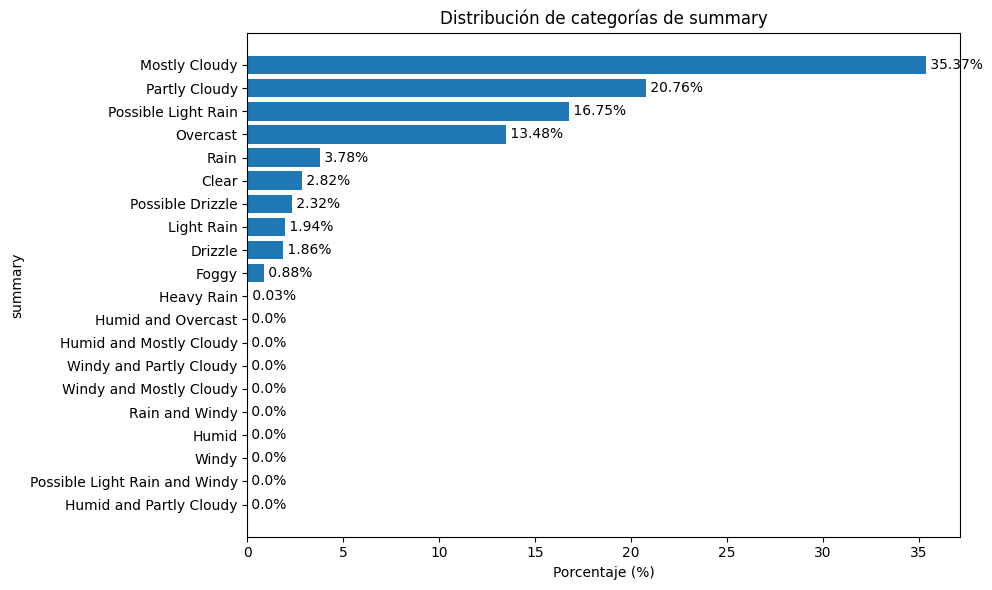

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# DISTRIBUCIÓN DE CATEGORÍAS DE summary
# =========================================================

dist_summary = (
    df_modelo["summary"]
    .fillna("Sin dato")
    .value_counts()
    .reset_index()
)

dist_summary.columns = ["summary", "cantidad"]
dist_summary["porcentaje"] = (
    dist_summary["cantidad"] / len(df_modelo) * 100
).round(2)

print(f"Categorías distintas en summary: {dist_summary.shape[0]}")
display(dist_summary)

# Gráfico
plt.figure(figsize=(10, 6))

plt.barh(
    dist_summary["summary"],
    dist_summary["porcentaje"]
)

plt.gca().invert_yaxis()
plt.title("Distribución de categorías de summary")
plt.xlabel("Porcentaje (%)")
plt.ylabel("summary")

for i, row in dist_summary.iterrows():
    plt.text(
        row["porcentaje"],
        i,
        f" {row['porcentaje']}%",
        va="center"
    )

plt.tight_layout()
plt.show()


In [17]:
# =========================================================
# AGRUPAR CATEGORÍAS RARAS DE summary COMO "Otros"
# =========================================================

categorias_otros = [
    "Humid and Overcast",
    "Humid and Mostly Cloudy",
    "Windy and Partly Cloudy",
    "Windy and Mostly Cloudy",
    "Rain and Windy",
    "Humid",
    "Windy",
    "Possible Light Rain and Windy",
    "Humid and Partly Cloudy"
]

df_modelo["summary_agrupado"] = df_modelo["summary"].replace(
    categorias_otros,
    "Otros"
)

# Revisar nueva distribución
dist_summary_agrupado = (
    df_modelo["summary_agrupado"]
    .fillna("Sin dato")
    .value_counts()
    .reset_index()
)

dist_summary_agrupado.columns = ["summary_agrupado", "cantidad"]
dist_summary_agrupado["porcentaje"] = (
    dist_summary_agrupado["cantidad"] / len(df_modelo) * 100
).round(2)

display(dist_summary_agrupado)

,summary_agrupado,cantidad,porcentaje
0,Mostly Cloudy,2630239,35.37
1,Partly Cloudy,1544022,20.76
2,Possible Light Rain,1245280,16.75
3,Overcast,1002614,13.48
4,Rain,281200,3.78
5,Clear,209775,2.82
6,Possible Drizzle,172237,2.32
7,Light Rain,144273,1.94
8,Drizzle,138422,1.86
9,Foggy,65649,0.88


In [18]:
import pandas as pd
import numpy as np

# =========================================================
# BLOQUE 5 — CODIFICAR BARRIO Y SUMMARY AGRUPADO PARA MODELADO
# =========================================================

df_features = df_modelo.copy()

# ---------------------------------------------------------
# 1. Crear barrio_id
# ---------------------------------------------------------

df_features["BARRIO"] = (
    df_features["BARRIO"]
    .astype(str)
    .str.strip()
    .str.lower()
)

barrios_ordenados = sorted(df_features["BARRIO"].unique())
BARRIO_MAP = {barrio: i for i, barrio in enumerate(barrios_ordenados)}

df_features["barrio_id"] = (
    df_features["BARRIO"]
    .map(BARRIO_MAP)
    .fillna(-1)
    .astype("int32")
)

print(f"Total barrios codificados: {len(BARRIO_MAP)}")

# ---------------------------------------------------------
# 2. Usar summary_agrupado ya existente
# ---------------------------------------------------------

if "summary_agrupado" not in df_features.columns:
    raise ValueError(
        "No existe la columna 'summary_agrupado'. "
        "Primero debes crearla agrupando categorías raras como 'Otros'."
    )

df_features["summary_agrupado"] = (
    df_features["summary_agrupado"]
    .fillna("Sin dato")
    .astype(str)
    .str.strip()
)

print("\nCategorías finales de summary_agrupado:")
display(
    df_features["summary_agrupado"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "summary_agrupado", "summary_agrupado": "cantidad"})
)

# ---------------------------------------------------------
# 3. One-Hot Encoding de summary_agrupado
# ---------------------------------------------------------

summary_ohe = pd.get_dummies(
    df_features["summary_agrupado"],
    prefix="summary",
    dtype=np.int8
)

df_features = pd.concat(
    [df_features, summary_ohe],
    axis=1
)

# ---------------------------------------------------------
# 4. Eliminar columnas que no entran directamente al modelo
# ---------------------------------------------------------

cols_eliminar_modelo = [
    # Llaves/texto original
    "TW",
    "BARRIO",
    "summary",
    "summary_agrupado",

    # Fecha/tiempo crudo o redundante
    "FECHA",
    "Hora",
    "Hora_num",
    "hora",
    "hora_dia",
    "Dia",
    "dia",
    "Mes",
    "mes",
    "Dia_sem",
    "Dia_Sem_REAL",
    "dia_semana",
    "dia_ano",
    "anio",
    "PERIODO",

    # Columnas espaciales o del accidente puntual
    "Lat",
    "Lon",

    # Columnas con nulos masivos / no disponibles para negativos
    "COMUNA",
    "comuna_ext",

    # Variables climáticas eliminadas por EDA
    "precipIntensity",
    "precipProbability",
    "visibility",
    "cloudCover",

    # Variable angular cruda si ya tienes sin/cos
    "windBearing",
    "windBearing_rad",

    # Auxiliares del histórico
    "registros_previos_barrio",
    "accidentes_previos_barrio"
]

df_features = df_features.drop(
    columns=cols_eliminar_modelo,
    errors="ignore"
)

# ---------------------------------------------------------
# 5. Revisar resultado final
# ---------------------------------------------------------

print("="*70)
print("DF_FEATURES FINAL PARA MODELADO")
print("="*70)

print("Shape:")
print(df_features.shape)

print("\nColumnas:")
print(df_features.columns.tolist())

print("\nNulos restantes:")
nulos = df_features.isna().sum().sort_values(ascending=False)
display(nulos[nulos > 0].to_frame("nulos"))

print("\nDistribución target:")
display(
    df_features["target"]
    .value_counts()
    .sort_index()
    .to_frame("cantidad")
    .assign(porcentaje=lambda x: (x["cantidad"] / len(df_features) * 100).round(2))
)

display(df_features.head())

Total barrios codificados: 318

Categorías finales de summary_agrupado:


,cantidad,count
0,Mostly Cloudy,2630239
1,Partly Cloudy,1544022
2,Possible Light Rain,1245280
3,Overcast,1002614
4,Rain,281200
5,Clear,209775
6,Possible Drizzle,172237
7,Light Rain,144273
8,Drizzle,138422
9,Foggy,65649


DF_FEATURES FINAL PARA MODELADO
Shape:
(7436188, 28)

Columnas:
['temperature', 'dewPoint', 'humidity', 'windSpeed', 'uvIndex', 'es_fin_semana', 'es_festivo', 'hora_sin', 'hora_cos', 'dia_semana_sin', 'dia_semana_cos', 'dia_ano_sin', 'dia_ano_cos', 'target', 'prom_accidentes_historico_barrio', 'barrio_id', 'summary_Clear', 'summary_Drizzle', 'summary_Foggy', 'summary_Heavy Rain', 'summary_Light Rain', 'summary_Mostly Cloudy', 'summary_Otros', 'summary_Overcast', 'summary_Partly Cloudy', 'summary_Possible Drizzle', 'summary_Possible Light Rain', 'summary_Rain']

Nulos restantes:


,nulos



Distribución target:


,cantidad,porcentaje
target,,
0,7323613,98.49
1,112575,1.51


,temperature,dewPoint,humidity,windSpeed,uvIndex,es_fin_semana,es_festivo,hora_sin,hora_cos,dia_semana_sin,...,summary_Foggy,summary_Heavy Rain,summary_Light Rain,summary_Mostly Cloudy,summary_Otros,summary_Overcast,summary_Partly Cloudy,summary_Possible Drizzle,summary_Possible Light Rain,summary_Rain
0,16.43,14.0,0.86,1.50,0.0,1,1,0.000000,1.000000,-0.781831,...,0,0,0,0,0,0,1,0,0,0
1,16.43,14.0,0.86,1.50,0.0,1,1,0.258819,0.965926,-0.781831,...,0,0,0,0,0,0,1,0,0,0
2,15.43,13.0,0.85,1.02,0.0,1,1,0.500000,0.866025,-0.781831,...,1,0,0,0,0,0,0,0,0,0
3,15.43,13.0,0.85,2.09,0.0,1,1,0.707107,0.707107,-0.781831,...,1,0,0,0,0,0,0,0,0,0
4,15.43,13.0,0.85,2.09,0.0,1,1,0.866025,0.500000,-0.781831,...,1,0,0,0,0,0,0,0,0,0


In [19]:
df_features[["barrio_id", "target", "prom_accidentes_historico_barrio"]].head()

,barrio_id,target,prom_accidentes_historico_barrio
0,0,0,0.0
1,0,0,0.0
2,0,0,0.0
3,0,0,0.0
4,0,0,0.0


In [22]:
print("barrio_id en df_modelo:", "barrio_id" in df_modelo.columns)
print("barrio_id en df_features:", "barrio_id" in df_features.columns)

barrio_id en df_modelo: True
barrio_id en df_features: True


In [24]:
# =========================================================
# BLOQUE 6 — SPLIT TEMPORAL LIMPIO POR FECHA DE CORTE
# =========================================================

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. Verificaciones básicas
# ---------------------------------------------------------

print("Shape df_modelo:", df_modelo.shape)
print("Shape df_features:", df_features.shape)

if len(df_modelo) != len(df_features):
    raise ValueError("df_modelo y df_features deben tener el mismo número de filas.")

if "target" not in df_features.columns:
    raise ValueError("df_features debe tener la columna target.")

if "TW" not in df_modelo.columns:
    raise ValueError("df_modelo debe conservar TW para hacer split temporal.")

# Reiniciar índices para asegurar alineación fila a fila
df_modelo_split = df_modelo.reset_index(drop=True).copy()
df_features_split = df_features.reset_index(drop=True).copy()

# ---------------------------------------------------------
# 2. Separar X e y
# ---------------------------------------------------------

X = df_features_split.drop(columns=["target"]).copy()
y = df_features_split["target"].astype(int).copy()

fechas = pd.to_datetime(df_modelo_split["TW"])

# ---------------------------------------------------------
# 3. Elegir fecha de corte usando el 80% de timestamps únicos
# ---------------------------------------------------------

fechas_unicas = np.sort(fechas.unique())

pos_corte = int(len(fechas_unicas) * 0.80)
fecha_corte = fechas_unicas[pos_corte]

print("="*70)
print("FECHA DE CORTE TEMPORAL")
print("="*70)
print("Fecha de corte:", fecha_corte)

# ---------------------------------------------------------
# 4. Crear máscaras temporales
# ---------------------------------------------------------

mask_train = fechas < fecha_corte
mask_test = fechas >= fecha_corte

X_train = X.loc[mask_train].copy()
y_train = y.loc[mask_train].copy()

X_test = X.loc[mask_test].copy()
y_test = y.loc[mask_test].copy()

fechas_train = fechas.loc[mask_train]
fechas_test = fechas.loc[mask_test]

# ---------------------------------------------------------
# 5. Reporte
# ---------------------------------------------------------

print("\n" + "="*70)
print("SPLIT TEMPORAL LIMPIO COMPLETADO")
print("="*70)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

print(f"\nRango train: {fechas_train.min()} → {fechas_train.max()}")
print(f"Rango test:  {fechas_test.min()} → {fechas_test.max()}")

print("\n¿La fecha máxima de train es menor que la mínima de test?")
print(fechas_train.max() < fechas_test.min())

print("\nDistribución y_train:")
display(
    y_train.value_counts()
    .sort_index()
    .to_frame("cantidad")
    .assign(porcentaje=lambda x: (x["cantidad"] / len(y_train) * 100).round(4))
)

print("\nDistribución y_test:")
display(
    y_test.value_counts()
    .sort_index()
    .to_frame("cantidad")
    .assign(porcentaje=lambda x: (x["cantidad"] / len(y_test) * 100).round(4))
)

Shape df_modelo: (7436188, 35)
Shape df_features: (7436188, 28)
FECHA DE CORTE TEMPORAL
Fecha de corte: 2019-06-11T02:00:00.000000

SPLIT TEMPORAL LIMPIO COMPLETADO
X_train: (5977776, 27)
X_test:  (1458412, 27)

Rango train: 2017-01-01 00:00:00 → 2019-06-11 01:00:00
Rango test:  2019-06-11 02:00:00 → 2019-12-31 23:00:00

¿La fecha máxima de train es menor que la mínima de test?
True

Distribución y_train:


,cantidad,porcentaje
target,,
0,5889718,98.5269
1,88058,1.4731



Distribución y_test:


,cantidad,porcentaje
target,,
0,1433895,98.3189
1,24517,1.6811


Al realizar una partición temporal 80/20, la proporción de accidentes en el conjunto de prueba fue mayor que en el conjunto de entrenamiento. Esto no corresponde a un error, sino a una diferencia real en la distribución temporal del target. Mientras que el entrenamiento conserva registros desde 2017 hasta junio de 2019, el conjunto de prueba contiene los meses finales de 2019, donde la tasa de accidentalidad fue ligeramente superior. Esta diferencia evidencia la importancia de validar temporalmente el modelo, ya que permite evaluar su capacidad de generalizar hacia periodos futuros.

In [25]:
# =========================================================
# BLOQUE 7 — BASELINE INGENUO: SIEMPRE PREDICE 0
# =========================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
    roc_auc_score
)

# Predicción ingenua: todo es 0, es decir, "no hubo accidente"
y_pred_baseline = np.zeros_like(y_test)

# Probabilidad ingenua: probabilidad 0 para accidente
y_proba_baseline = np.zeros_like(y_test, dtype=float)

# Métricas
accuracy = accuracy_score(y_test, y_pred_baseline)
precision = precision_score(y_test, y_pred_baseline, zero_division=0)
recall = recall_score(y_test, y_pred_baseline, zero_division=0)
f1 = f1_score(y_test, y_pred_baseline, zero_division=0)
pr_auc = average_precision_score(y_test, y_proba_baseline)

print("="*70)
print("BASELINE INGENUO: SIEMPRE PREDICE 0")
print("="*70)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"PR-AUC / Average Precision: {pr_auc:.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_baseline)

cm_df = pd.DataFrame(
    cm,
    index=["Real 0", "Real 1"],
    columns=["Pred 0", "Pred 1"]
)

print("\nMatriz de confusión:")
display(cm_df)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_baseline, zero_division=0))

BASELINE INGENUO: SIEMPRE PREDICE 0
Accuracy:  0.9832
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000
PR-AUC / Average Precision: 0.0168

Matriz de confusión:


,Pred 0,Pred 1
Real 0,1433895,0
Real 1,24517,0



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99   1433895
           1       0.00      0.00      0.00     24517

    accuracy                           0.98   1458412
   macro avg       0.49      0.50      0.50   1458412
weighted avg       0.97      0.98      0.97   1458412



In [26]:
# =========================================================
# BLOQUE 8 — PRIMER MODELO REAL: SGDClassifier BALANCEADO
# =========================================================

import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
    roc_auc_score
)

# ---------------------------------------------------------
# 1. Modelo
# ---------------------------------------------------------
# SGDClassifier con loss="log_loss" funciona como una regresión logística eficiente.
# class_weight="balanced" le da más peso a la clase minoritaria.

modelo_sgd = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", SGDClassifier(
        loss="log_loss",
        class_weight="balanced",
        max_iter=1000,
        tol=1e-3,
        random_state=42,
        n_jobs=-1
    ))
])

print("="*70)
print("ENTRENANDO MODELO SGD BALANCEADO")
print("="*70)

modelo_sgd.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

# ---------------------------------------------------------
# 2. Predicciones
# ---------------------------------------------------------

y_pred_sgd = modelo_sgd.predict(X_test)
y_proba_sgd = modelo_sgd.predict_proba(X_test)[:, 1]

# ---------------------------------------------------------
# 3. Métricas
# ---------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred_sgd)
precision = precision_score(y_test, y_pred_sgd, zero_division=0)
recall = recall_score(y_test, y_pred_sgd, zero_division=0)
f1 = f1_score(y_test, y_pred_sgd, zero_division=0)
pr_auc = average_precision_score(y_test, y_proba_sgd)
roc_auc = roc_auc_score(y_test, y_proba_sgd)

print("\n" + "="*70)
print("RESULTADOS MODELO SGD BALANCEADO")
print("="*70)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"PR-AUC / Average Precision: {pr_auc:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# ---------------------------------------------------------
# 4. Matriz de confusión
# ---------------------------------------------------------

cm = confusion_matrix(y_test, y_pred_sgd)

cm_df = pd.DataFrame(
    cm,
    index=["Real 0", "Real 1"],
    columns=["Pred 0", "Pred 1"]
)

print("\nMatriz de confusión:")
display(cm_df)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_sgd, zero_division=0))

ENTRENANDO MODELO SGD BALANCEADO
Modelo entrenado correctamente.

RESULTADOS MODELO SGD BALANCEADO
Accuracy:  0.7764
Precision: 0.0462
Recall:    0.6259
F1-score:  0.0860
PR-AUC / Average Precision: 0.0723
ROC-AUC:   0.7768

Matriz de confusión:


,Pred 0,Pred 1
Real 0,1117013,316882
Real 1,9172,15345



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      0.78      0.87   1433895
           1       0.05      0.63      0.09     24517

    accuracy                           0.78   1458412
   macro avg       0.52      0.70      0.48   1458412
weighted avg       0.98      0.78      0.86   1458412



,umbral,precision,recall,f1,verdaderos_positivos,falsos_positivos,falsos_negativos,verdaderos_negativos
0,0.05,0.0168,0.9999,0.0331,24514,1433771,3,124
1,0.10,0.0172,0.9982,0.0337,24472,1402138,45,31757
2,0.15,0.0187,0.9867,0.0367,24191,1268838,326,165057
3,0.20,0.0207,0.9644,0.0406,23645,1116827,872,317068
4,0.25,0.0230,0.9309,0.0450,22823,967599,1694,466296
5,0.30,0.0261,0.8878,0.0506,21767,813719,2750,620176
6,0.35,0.0298,0.8327,0.0576,20416,664237,4101,769658
7,0.40,0.0345,0.7711,0.0661,18905,528596,5612,905299
8,0.45,0.0400,0.7007,0.0757,17178,412416,7339,1021479
9,0.50,0.0462,0.6259,0.0860,15345,316882,9172,1117013


MEJOR UMBRAL SEGÚN F1


,umbral,precision,recall,f1,verdaderos_positivos,falsos_positivos,falsos_negativos,verdaderos_negativos
15,0.8,0.0928,0.2917,0.1409,7152.0,69880.0,17365.0,1364015.0


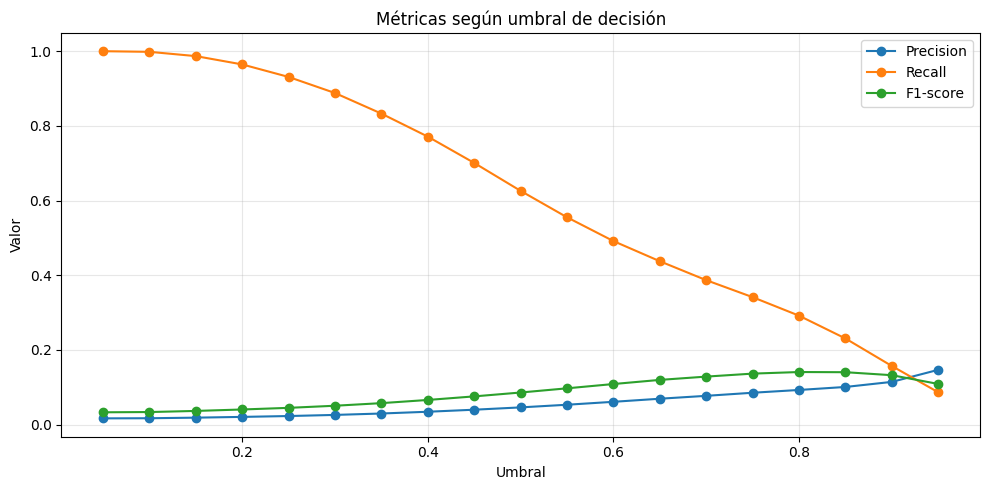

In [27]:
# =========================================================
# BLOQUE 9 — AJUSTE DE UMBRAL PARA SGD BALANCEADO
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Probabilidades del modelo SGD ya entrenado
# y_proba_sgd = modelo_sgd.predict_proba(X_test)[:, 1]

umbrales = np.arange(0.05, 0.96, 0.05)

resultados_umbrales = []

for umbral in umbrales:
    y_pred_umbral = (y_proba_sgd >= umbral).astype(int)
    
    precision = precision_score(y_test, y_pred_umbral, zero_division=0)
    recall = recall_score(y_test, y_pred_umbral, zero_division=0)
    f1 = f1_score(y_test, y_pred_umbral, zero_division=0)
    
    cm = confusion_matrix(y_test, y_pred_umbral)
    
    tn, fp, fn, tp = cm.ravel()
    
    resultados_umbrales.append({
        "umbral": umbral,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "verdaderos_positivos": tp,
        "falsos_positivos": fp,
        "falsos_negativos": fn,
        "verdaderos_negativos": tn
    })

df_umbrales = pd.DataFrame(resultados_umbrales)

display(df_umbrales.round(4))

# Mejor umbral según F1
mejor_f1 = df_umbrales.loc[df_umbrales["f1"].idxmax()]

print("="*70)
print("MEJOR UMBRAL SEGÚN F1")
print("="*70)
display(mejor_f1.to_frame().T.round(4))

# Gráfico precision, recall y f1 por umbral
plt.figure(figsize=(10, 5))

plt.plot(df_umbrales["umbral"], df_umbrales["precision"], marker="o", label="Precision")
plt.plot(df_umbrales["umbral"], df_umbrales["recall"], marker="o", label="Recall")
plt.plot(df_umbrales["umbral"], df_umbrales["f1"], marker="o", label="F1-score")

plt.title("Métricas según umbral de decisión")
plt.xlabel("Umbral")
plt.ylabel("Valor")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# =========================================================
# BLOQUE 10 — MÉTRICAS FINALES CON UMBRAL SELECCIONADO
# =========================================================

import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
    roc_auc_score
)

UMBRAL_FINAL = 0.80

y_pred_sgd_final = (y_proba_sgd >= UMBRAL_FINAL).astype(int)

accuracy_final = accuracy_score(y_test, y_pred_sgd_final)
precision_final = precision_score(y_test, y_pred_sgd_final, zero_division=0)
recall_final = recall_score(y_test, y_pred_sgd_final, zero_division=0)
f1_final = f1_score(y_test, y_pred_sgd_final, zero_division=0)
pr_auc_final = average_precision_score(y_test, y_proba_sgd)
roc_auc_final = roc_auc_score(y_test, y_proba_sgd)

cm_final = confusion_matrix(y_test, y_pred_sgd_final)
tn, fp, fn, tp = cm_final.ravel()

metricas_finales = pd.DataFrame([
    {
        "modelo": "Baseline siempre 0",
        "umbral": "-",
        "accuracy": accuracy_score(y_test, np.zeros_like(y_test)),
        "precision": precision_score(y_test, np.zeros_like(y_test), zero_division=0),
        "recall": recall_score(y_test, np.zeros_like(y_test), zero_division=0),
        "f1": f1_score(y_test, np.zeros_like(y_test), zero_division=0),
        "pr_auc": average_precision_score(y_test, np.zeros_like(y_test, dtype=float)),
        "roc_auc": np.nan,
        "tp": 0,
        "fp": 0,
        "fn": int((y_test == 1).sum()),
        "tn": int((y_test == 0).sum())
    },
    {
        "modelo": "SGD balanceado",
        "umbral": UMBRAL_FINAL,
        "accuracy": accuracy_final,
        "precision": precision_final,
        "recall": recall_final,
        "f1": f1_final,
        "pr_auc": pr_auc_final,
        "roc_auc": roc_auc_final,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    }
])

display(metricas_finales.round(4))

print("="*70)
print(f"MATRIZ DE CONFUSIÓN — SGD BALANCEADO UMBRAL {UMBRAL_FINAL}")
print("="*70)

display(pd.DataFrame(
    cm_final,
    index=["Real 0", "Real 1"],
    columns=["Pred 0", "Pred 1"]
))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_sgd_final, zero_division=0))

,modelo,umbral,accuracy,precision,recall,f1,pr_auc,roc_auc,tp,fp,fn,tn
0,Baseline siempre 0,-,0.9832,0.0000,0.0000,0.0000,0.0168,NaN,0,0,24517,1433895
1,SGD balanceado,0.8,0.9402,0.0928,0.2917,0.1409,0.0723,0.7768,7152,69880,17365,1364015


MATRIZ DE CONFUSIÓN — SGD BALANCEADO UMBRAL 0.8


,Pred 0,Pred 1
Real 0,1364015,69880
Real 1,17365,7152



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97   1433895
           1       0.09      0.29      0.14     24517

    accuracy                           0.94   1458412
   macro avg       0.54      0.62      0.55   1458412
weighted avg       0.97      0.94      0.96   1458412



In [35]:
# =========================================================
# EXPORTAR MÉTRICAS BASELINE + SGD PARA COMPARACIÓN
# =========================================================
from pathlib import Path

ARTIFACTS_DIR = Path("../Modelado/artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

ruta_metricas = ARTIFACTS_DIR / "metricas_baseline_sgd.csv"
metricas_finales.to_csv(ruta_metricas, index=False)

print(f"Métricas (baseline + SGD) guardadas en: {ruta_metricas.resolve()}")
display(metricas_finales.round(4))

Métricas (baseline + SGD) guardadas en: C:\Users\camil\OneDrive\Documentos\Aprendizaje de Maquina\Taller\Modelado\artifacts\metricas_baseline_sgd.csv


,modelo,umbral,accuracy,precision,recall,f1,pr_auc,roc_auc,tp,fp,fn,tn
0,Baseline siempre 0,-,0.9832,0.0000,0.0000,0.0000,0.0168,NaN,0,0,24517,1433895
1,SGD balanceado,0.8,0.9402,0.0928,0.2917,0.1409,0.0723,0.7768,7152,69880,17365,1364015


VARIABLES MÁS IMPORTANTES SEGÚN SGD


,variable,coeficiente,importancia_abs
13,prom_accidentes_historico_barrio,0.810983,0.810983
8,hora_cos,-0.746725,0.746725
4,uvIndex,-0.444459,0.444459
7,hora_sin,-0.198793,0.198793
5,es_fin_semana,-0.117432,0.117432
6,es_festivo,-0.100756,0.100756
2,humidity,-0.090821,0.090821
25,summary_Possible Light Rain,-0.066642,0.066642
0,temperature,0.065834,0.065834
14,barrio_id,-0.058377,0.058377


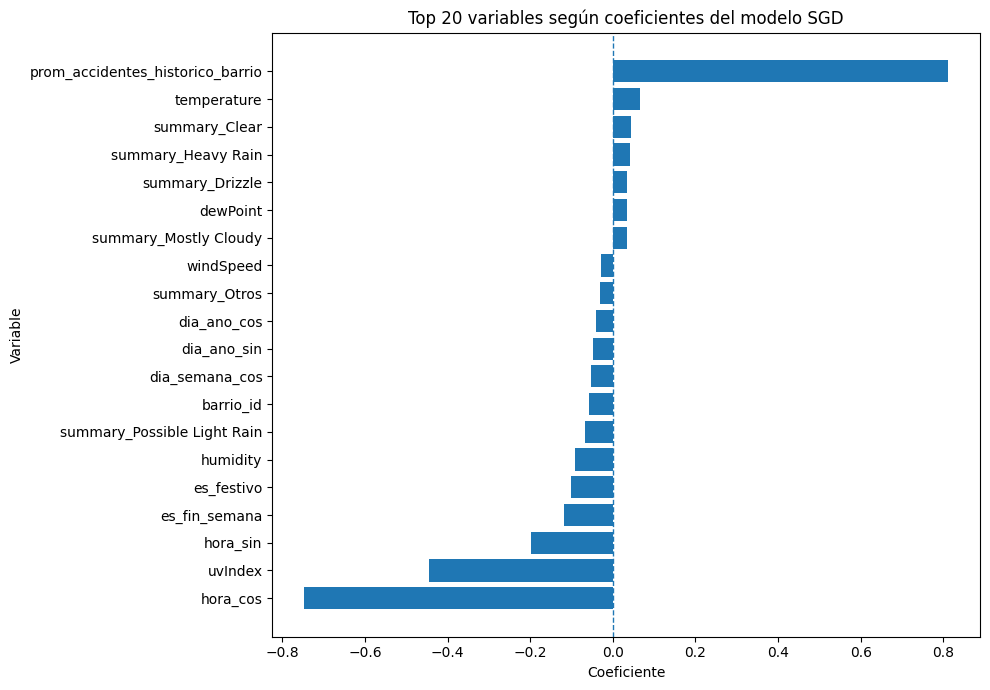

In [30]:
# =========================================================
# BLOQUE 11 — IMPORTANCIA DE VARIABLES DEL MODELO SGD
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Obtener nombres de variables
feature_names = X_train.columns

# Obtener coeficientes del modelo dentro del pipeline
coeficientes = modelo_sgd.named_steps["clf"].coef_[0]

importancia_sgd = pd.DataFrame({
    "variable": feature_names,
    "coeficiente": coeficientes,
    "importancia_abs": np.abs(coeficientes)
})

# Ordenar por importancia absoluta
importancia_sgd = importancia_sgd.sort_values(
    "importancia_abs",
    ascending=False
)

print("="*70)
print("VARIABLES MÁS IMPORTANTES SEGÚN SGD")
print("="*70)

display(importancia_sgd.head(20))

# Gráfico top 20
top_n = 20
top_importancia = importancia_sgd.head(top_n).sort_values("coeficiente")

plt.figure(figsize=(10, 7))
plt.barh(top_importancia["variable"], top_importancia["coeficiente"])
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Top 20 variables según coeficientes del modelo SGD")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## Exportar CSVs para `modeladoRandomForest.ipynb`

Ejecuta **después del BLOQUE 6** (split temporal). No exportes el universo completo (7,4M filas): no cabe en RAM al leer.

| Archivo | Uso |
|---------|-----|
| `train_balanceado.csv` | Entrenar RF (~180k filas) |
| `test_modelo.csv` | Evaluar en test (~1,5M filas) |
| `Modelado/artifacts/split_meta.json` | `fecha_corte` |

In [34]:
import json
from pathlib import Path

RANDOM_STATE = 42
RUTA_TRUSTED = Path("../Datos/Trusted")
RUTA_ARTIFACTS = Path("../Modelado/artifacts")
RUTA_TRUSTED.mkdir(parents=True, exist_ok=True)
RUTA_ARTIFACTS.mkdir(parents=True, exist_ok=True)

for nombre in ("X_train", "y_train", "X_test", "y_test", "fecha_corte", "df_modelo_split", "mask_train", "mask_test"):
    if nombre not in globals():
        raise NameError(f"Falta '{nombre}'. Ejecuta antes el BLOQUE 6 (split temporal).")

# --- 1) Muestra balanceada para entrenar (~2 × positivos) ---
pos_idx = y_train[y_train == 1].index
n_pos = len(pos_idx)
neg_sample_idx = y_train[y_train == 0].sample(n=n_pos, random_state=RANDOM_STATE).index
idx_bal = pos_idx.union(neg_sample_idx)

train_bal = X_train.loc[idx_bal].copy()
train_bal.insert(0, "TW", pd.to_datetime(df_modelo_split.loc[mask_train, "TW"].loc[idx_bal]).values)
train_bal.insert(1, "BARRIO", df_modelo_split.loc[mask_train, "BARRIO"].loc[idx_bal].astype(str).values)
train_bal["target"] = y_train.loc[idx_bal].values

RUTA_TRAIN = RUTA_TRUSTED / "train_balanceado.csv"
train_bal.to_csv(RUTA_TRAIN, index=False)
print(f"train_balanceado.csv: {len(train_bal):,} filas")

# --- 2) Test completo (más liviano que 7,4M) ---
test_out = X_test.copy()
test_out.insert(0, "TW", pd.to_datetime(df_modelo_split.loc[mask_test, "TW"]).values)
test_out.insert(1, "BARRIO", df_modelo_split.loc[mask_test, "BARRIO"].astype(str).values)
test_out["target"] = y_test.values

RUTA_TEST = RUTA_TRUSTED / "test_modelo.csv"
print(f"Guardando test_modelo.csv ({len(test_out):,} filas)...")
test_out.to_csv(RUTA_TEST, index=False)

# --- 3) Metadata del split ---
meta = {
    "fecha_corte": str(fecha_corte),
    "random_state": RANDOM_STATE,
    "n_train_bal": int(len(train_bal)),
    "n_test": int(len(test_out)),
    "feature_columns": [c for c in X_train.columns],
}
(RUTA_ARTIFACTS / "split_meta.json").write_text(
    json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8"
)

print("\nExportado:")
print(" ", RUTA_TRAIN.resolve())
print(" ", RUTA_TEST.resolve())
print(" ", (RUTA_ARTIFACTS / "split_meta.json").resolve())
print("→ modeladoRandomForest.ipynb (no uses datos_modelo.csv completo)")

train_balanceado.csv: 176,116 filas
Guardando test_modelo.csv (1,458,412 filas)...

Exportado:
  C:\Users\camil\OneDrive\Documentos\Aprendizaje de Maquina\Taller\Datos\Trusted\train_balanceado.csv
  C:\Users\camil\OneDrive\Documentos\Aprendizaje de Maquina\Taller\Datos\Trusted\test_modelo.csv
  C:\Users\camil\OneDrive\Documentos\Aprendizaje de Maquina\Taller\Modelado\artifacts\split_meta.json
→ modeladoRandomForest.ipynb (no uses datos_modelo.csv completo)


In [36]:
# =========================================================
# CHUNK — AJUSTE DE HIPERPARÁMETROS SGD BALANCEADO
# Validación interna sobre X_train / y_train
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score
)

RANDOM_STATE = 42

# ---------------------------------------------------------
# 1. Verificar objetos necesarios
# ---------------------------------------------------------

objetos_necesarios = ["X_train", "y_train"]

for obj in objetos_necesarios:
    if obj not in globals():
        raise ValueError(f"No existe {obj}. Debes tener primero el split temporal.")

print("Objetos encontrados:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

# ---------------------------------------------------------
# 2. Crear validación interna temporal
# ---------------------------------------------------------
# X_train ya viene ordenado temporalmente, entonces:
# primeros 80% de train -> tuning
# últimos 20% de train -> validación

punto_corte_val = int(len(X_train) * 0.80)

X_sgd_tune = X_train.iloc[:punto_corte_val].copy()
y_sgd_tune = y_train.iloc[:punto_corte_val].copy()

X_sgd_val = X_train.iloc[punto_corte_val:].copy()
y_sgd_val = y_train.iloc[punto_corte_val:].copy()

print("\n" + "="*70)
print("VALIDACIÓN INTERNA SGD")
print("="*70)

print("X_sgd_tune:", X_sgd_tune.shape)
print("X_sgd_val:", X_sgd_val.shape)

print("\nDistribución y_sgd_tune:")
display(
    y_sgd_tune.value_counts()
    .sort_index()
    .to_frame("cantidad")
    .assign(porcentaje=lambda x: (x["cantidad"] / len(y_sgd_tune) * 100).round(4))
)

print("\nDistribución y_sgd_val:")
display(
    y_sgd_val.value_counts()
    .sort_index()
    .to_frame("cantidad")
    .assign(porcentaje=lambda x: (x["cantidad"] / len(y_sgd_val) * 100).round(4))
)

# ---------------------------------------------------------
# 3. Grilla pequeña de hiperparámetros
# ---------------------------------------------------------

configs_sgd = [
    {
        "alpha": 0.0001,
        "penalty": "l2",
        "max_iter": 1000
    },
    {
        "alpha": 0.00005,
        "penalty": "l2",
        "max_iter": 1000
    },
    {
        "alpha": 0.0005,
        "penalty": "l2",
        "max_iter": 1000
    },
    {
        "alpha": 0.0001,
        "penalty": "elasticnet",
        "max_iter": 1000
    },
    {
        "alpha": 0.00005,
        "penalty": "elasticnet",
        "max_iter": 1000
    }
]

umbrales = np.arange(0.50, 0.96, 0.05)

resultados_tuning_sgd = []

# ---------------------------------------------------------
# 4. Entrenar cada configuración y validar
# ---------------------------------------------------------

for i, params in enumerate(configs_sgd, start=1):
    print(f"\nEntrenando configuración {i}/{len(configs_sgd)}:")
    print(params)

    modelo_tmp = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("clf", SGDClassifier(
            loss="log_loss",
            class_weight="balanced",
            alpha=params["alpha"],
            penalty=params["penalty"],
            max_iter=params["max_iter"],
            tol=1e-3,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    modelo_tmp.fit(X_sgd_tune, y_sgd_tune)

    proba_val = modelo_tmp.predict_proba(X_sgd_val)[:, 1]

    pr_auc = average_precision_score(y_sgd_val, proba_val)
    roc_auc = roc_auc_score(y_sgd_val, proba_val)

    mejor_f1 = -1
    mejor_umbral = None
    mejor_precision = None
    mejor_recall = None

    for umbral in umbrales:
        pred_val = (proba_val >= umbral).astype(int)

        precision = precision_score(y_sgd_val, pred_val, zero_division=0)
        recall = recall_score(y_sgd_val, pred_val, zero_division=0)
        f1 = f1_score(y_sgd_val, pred_val, zero_division=0)

        if f1 > mejor_f1:
            mejor_f1 = f1
            mejor_umbral = umbral
            mejor_precision = precision
            mejor_recall = recall

    resultados_tuning_sgd.append({
        "config_id": i,
        "alpha": params["alpha"],
        "penalty": params["penalty"],
        "max_iter": params["max_iter"],
        "mejor_umbral_val": mejor_umbral,
        "precision_val": mejor_precision,
        "recall_val": mejor_recall,
        "f1_val": mejor_f1,
        "pr_auc_val": pr_auc,
        "roc_auc_val": roc_auc
    })

df_tuning_sgd = pd.DataFrame(resultados_tuning_sgd)

df_tuning_sgd = df_tuning_sgd.sort_values(
    ["f1_val", "pr_auc_val", "roc_auc_val"],
    ascending=False
).reset_index(drop=True)

print("\n" + "="*70)
print("RESULTADOS TUNING SGD")
print("="*70)

display(df_tuning_sgd.round(4))

mejor_config_sgd = df_tuning_sgd.iloc[0]

print("\nMejor configuración SGD:")
display(mejor_config_sgd.to_frame().T.round(4))

Objetos encontrados:
X_train: (5977776, 27)
y_train: (5977776,)

VALIDACIÓN INTERNA SGD
X_sgd_tune: (4782220, 27)
X_sgd_val: (1195556, 27)

Distribución y_sgd_tune:


,cantidad,porcentaje
target,,
0,4711038,98.5115
1,71182,1.4885



Distribución y_sgd_val:


,cantidad,porcentaje
target,,
0,1178680,98.5884
1,16876,1.4116



Entrenando configuración 1/5:
{'alpha': 0.0001, 'penalty': 'l2', 'max_iter': 1000}

Entrenando configuración 2/5:
{'alpha': 5e-05, 'penalty': 'l2', 'max_iter': 1000}

Entrenando configuración 3/5:
{'alpha': 0.0005, 'penalty': 'l2', 'max_iter': 1000}

Entrenando configuración 4/5:
{'alpha': 0.0001, 'penalty': 'elasticnet', 'max_iter': 1000}

Entrenando configuración 5/5:
{'alpha': 5e-05, 'penalty': 'elasticnet', 'max_iter': 1000}

RESULTADOS TUNING SGD


,config_id,alpha,penalty,max_iter,mejor_umbral_val,precision_val,recall_val,f1_val,pr_auc_val,roc_auc_val
0,5,0.0000,elasticnet,1000,0.85,0.0871,0.2628,0.1309,0.0657,0.7861
1,4,0.0001,elasticnet,1000,0.85,0.0876,0.2494,0.1297,0.0661,0.7919
2,3,0.0005,l2,1000,0.85,0.0875,0.2422,0.1286,0.0653,0.7947
3,1,0.0001,l2,1000,0.85,0.0871,0.2438,0.1284,0.0659,0.7933
4,2,0.0000,l2,1000,0.85,0.0855,0.2469,0.1270,0.0636,0.7905



Mejor configuración SGD:


,config_id,alpha,penalty,max_iter,mejor_umbral_val,precision_val,recall_val,f1_val,pr_auc_val,roc_auc_val
0,5,0.00005,elasticnet,1000,0.85,0.087128,0.262799,0.130868,0.065741,0.786135


In [39]:
# =========================================================
# CHUNK — ENTRENAR SGD FINAL CON MEJORES HIPERPARÁMETROS
# Estrategia memoria-segura:
#   - Train: train_balanceado.csv (~176k filas, 50/50)
#   - Test:  test_modelo.csv leído POR CHUNKS
# Libera X_train / X_test del Join para no quedarse sin RAM.
# =========================================================

import gc
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
    roc_auc_score,
)

RUTA_TRAIN_BAL = Path("../Datos/Trusted/train_balanceado.csv")
RUTA_TEST = Path("../Datos/Trusted/test_modelo.csv")
CHUNK_PRED = 200_000

# ---------------------------------------------------------
# 1. Liberar memoria de objetos pesados del Join
# ---------------------------------------------------------
for v in [
    "X_sgd_tune", "y_sgd_tune", "X_sgd_val", "y_sgd_val",
    "modelo_tmp", "proba_val", "pred_val",
    "resultados_tuning_sgd", "df_tuning_sgd",
    "X_train_bal_ord", "y_train_bal_ord", "fechas_train_bal_ord",
    "X_train", "y_train", "X_test",
]:
    if v in globals():
        del globals()[v]
gc.collect()

# ---------------------------------------------------------
# 2. Cargar train balanceado (~176k filas, 50/50)
# ---------------------------------------------------------
if not RUTA_TRAIN_BAL.exists():
    raise FileNotFoundError(
        f"No existe {RUTA_TRAIN_BAL}. "
        "Ejecuta antes la celda de exportación (BLOQUE 6 + exportar)."
    )

train_bal = pd.read_csv(RUTA_TRAIN_BAL, parse_dates=["TW"], low_memory=False)
print(f"train_balanceado: {train_bal.shape[0]:,} filas x {train_bal.shape[1]} cols")

cols_excluir = {"target", "TW", "BARRIO", "summary", "summary_agrupado"}
cols_X_sgd = [
    c for c in train_bal.columns
    if c not in cols_excluir and pd.api.types.is_numeric_dtype(train_bal[c])
]
print(f"Features usadas: {len(cols_X_sgd)}")

X_train_bal_sgd = train_bal[cols_X_sgd].astype(np.float32)
y_train_bal_sgd = train_bal["target"].astype(int)

del train_bal
gc.collect()

# ---------------------------------------------------------
# 3. Pipeline SGD tuned
#    train_balanceado ya está 50/50, no necesita class_weight
# ---------------------------------------------------------
modelo_sgd_tuned = Pipeline(steps=[
    ("scaler", StandardScaler(copy=False)),
    ("clf", SGDClassifier(
        loss="log_loss",
        alpha=0.00005,
        penalty="elasticnet",
        max_iter=1000,
        tol=1e-3,
        random_state=42,
        n_jobs=-1,
    )),
])

print("=" * 70)
print("ENTRENANDO SGD TUNED EN train_balanceado")
print("=" * 70)

modelo_sgd_tuned.fit(X_train_bal_sgd, y_train_bal_sgd)
gc.collect()
print("Modelo SGD tuned entrenado correctamente.")

# ---------------------------------------------------------
# 4. Predicción sobre test por chunks desde CSV
# ---------------------------------------------------------
if not RUTA_TEST.exists():
    raise FileNotFoundError(f"No existe {RUTA_TEST}. Exporta test_modelo.csv.")

print("\nPrediciendo test por chunks desde CSV...")
y_true_all = []
y_proba_all = []
for i, chunk in enumerate(pd.read_csv(
    RUTA_TEST, parse_dates=["TW"], chunksize=CHUNK_PRED, low_memory=False
)):
    y_chunk = chunk["target"].astype(int).to_numpy()
    X_chunk = chunk[cols_X_sgd].astype(np.float32)
    proba_chunk = modelo_sgd_tuned.predict_proba(X_chunk)[:, 1]
    y_true_all.append(y_chunk)
    y_proba_all.append(proba_chunk)
    if (i + 1) % 5 == 0:
        print(f"  chunk {i + 1}...")

y_test = np.concatenate(y_true_all)
y_proba_sgd_tuned = np.concatenate(y_proba_all)
del y_true_all, y_proba_all
gc.collect()

print(f"Test concatenado: {len(y_test):,} filas")

# ---------------------------------------------------------
# 5. Umbral final (seleccionado en validación interna)
# ---------------------------------------------------------
UMBRAL_SGD_TUNED = 0.85
y_pred_sgd_tuned = (y_proba_sgd_tuned >= UMBRAL_SGD_TUNED).astype(int)

accuracy = accuracy_score(y_test, y_pred_sgd_tuned)
precision = precision_score(y_test, y_pred_sgd_tuned, zero_division=0)
recall = recall_score(y_test, y_pred_sgd_tuned, zero_division=0)
f1 = f1_score(y_test, y_pred_sgd_tuned, zero_division=0)
pr_auc = average_precision_score(y_test, y_proba_sgd_tuned)
roc_auc = roc_auc_score(y_test, y_proba_sgd_tuned)

cm = confusion_matrix(y_test, y_pred_sgd_tuned)
tn, fp, fn, tp = cm.ravel()

metricas_sgd_tuned_final = pd.DataFrame([{
    "modelo": "SGD tuned",
    "umbral": UMBRAL_SGD_TUNED,
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "pr_auc": pr_auc,
    "roc_auc": roc_auc,
    "tp": tp,
    "fp": fp,
    "fn": fn,
    "tn": tn,
}])

display(metricas_sgd_tuned_final.round(4))

print("=" * 70)
print(f"MATRIZ DE CONFUSIÓN — SGD TUNED UMBRAL {UMBRAL_SGD_TUNED}")
print("=" * 70)
display(pd.DataFrame(
    cm,
    index=["Real 0", "Real 1"],
    columns=["Pred 0", "Pred 1"],
))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_sgd_tuned, zero_division=0))

# ---------------------------------------------------------
# 6. Reexportar CSV para comparacion_modelos.ipynb
# ---------------------------------------------------------
y_test_arr = np.asarray(y_test)
y_zeros = np.zeros_like(y_test_arr)

metricas_baseline_para_export = {
    "modelo": "Baseline siempre 0",
    "umbral": "-",
    "accuracy": accuracy_score(y_test_arr, y_zeros),
    "precision": precision_score(y_test_arr, y_zeros, zero_division=0),
    "recall": recall_score(y_test_arr, y_zeros, zero_division=0),
    "f1": f1_score(y_test_arr, y_zeros, zero_division=0),
    "pr_auc": average_precision_score(y_test_arr, y_zeros.astype(float)),
    "roc_auc": np.nan,
    "tp": 0,
    "fp": 0,
    "fn": int((y_test_arr == 1).sum()),
    "tn": int((y_test_arr == 0).sum()),
}

metricas_finales_export = pd.concat([
    pd.DataFrame([metricas_baseline_para_export]),
    metricas_sgd_tuned_final,
], ignore_index=True)

ARTIFACTS_DIR = Path("../Modelado/artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

ruta_metricas = ARTIFACTS_DIR / "metricas_baseline_sgd.csv"
metricas_finales_export.to_csv(ruta_metricas, index=False)

print(f"\nMétricas (baseline + SGD tuned) guardadas en: {ruta_metricas.resolve()}")
display(metricas_finales_export.round(4))

train_balanceado: 176,116 filas x 30 cols
Features usadas: 27
ENTRENANDO SGD TUNED EN train_balanceado
Modelo SGD tuned entrenado correctamente.

Prediciendo test por chunks desde CSV...
  chunk 5...
Test concatenado: 1,458,412 filas


,modelo,umbral,accuracy,precision,recall,f1,pr_auc,roc_auc,tp,fp,fn,tn
0,SGD tuned,0.85,0.9504,0.1012,0.2475,0.1436,0.0739,0.7747,6069,53922,18448,1379973


MATRIZ DE CONFUSIÓN — SGD TUNED UMBRAL 0.85


,Pred 0,Pred 1
Real 0,1379973,53922
Real 1,18448,6069



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97   1433895
           1       0.10      0.25      0.14     24517

    accuracy                           0.95   1458412
   macro avg       0.54      0.60      0.56   1458412
weighted avg       0.97      0.95      0.96   1458412


Métricas (baseline + SGD tuned) guardadas en: C:\Users\camil\OneDrive\Documentos\Aprendizaje de Maquina\Taller\Modelado\artifacts\metricas_baseline_sgd.csv


,modelo,umbral,accuracy,precision,recall,f1,pr_auc,roc_auc,tp,fp,fn,tn
0,Baseline siempre 0,-,0.9832,0.0000,0.0000,0.0000,0.0168,NaN,0,0,24517,1433895
1,SGD tuned,0.85,0.9504,0.1012,0.2475,0.1436,0.0739,0.7747,6069,53922,18448,1379973
